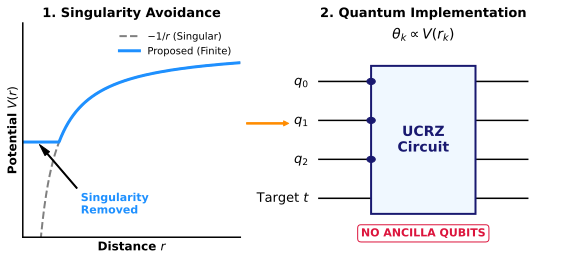

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# グラフのスタイル設定（論文向けにフォントや線幅を調整）
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Figureの作成（JCTCのTOC標準サイズに近い横長のアスペクト比）
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('white')

# ==========================================
# 左側：ポテンシャル（Problem & Solution）
# ==========================================
r = np.linspace(0.01, 3.0, 500)
v_coulomb = -1 / r

# 提案手法（実効距離 delta_r / 2 でカットオフした場合のモデル）
r_cutoff = 0.5
v_proposed = np.where(r > r_cutoff, -1/r, -1/r_cutoff)

# グラフの描画
ax1.plot(r, v_coulomb, '--', color='gray', linewidth=2, label='$-1/r$ (Singular)')
ax1.plot(r, v_proposed, '-', color='dodgerblue', linewidth=3, label='Proposed (Finite)')

# 軸とラベルの設定
ax1.set_xlim(0, 3)
ax1.set_ylim(-4, 0.5)
ax1.set_xlabel('Distance $r$', fontweight='bold')
ax1.set_ylabel('Potential $V(r)$', fontweight='bold')
ax1.set_xticks([]) # TOC図としてスッキリさせるため目盛りを消去
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 注釈と凡例
ax1.annotate('Singularity\nRemoved', xy=(0.2, -2.0), xytext=(0.8, -3.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=11, fontweight='bold', color='dodgerblue')
ax1.legend(loc='upper right', frameon=False, fontsize=10)
ax1.set_title('1. Singularity Avoidance', fontsize=13, fontweight='bold')

# ==========================================
# 右側：量子回路（Implementation）
# ==========================================
ax2.axis('off')
ax2.set_xlim(0, 5)
ax2.set_ylim(-1, 4.5)

# Qubitのラインを描画
y_coords = [3, 2, 1, 0]
labels = ['$q_0$', '$q_1$', '$q_2$', 'Target $t$']
for i, y in enumerate(y_coords):
    ax2.plot([0.5, 4.5], [y, y], color='black', lw=1.5)
    ax2.text(0.3, y, labels[i], va='center', ha='right', fontsize=13)

# UCRZブロックの描画
rect = patches.Rectangle((1.5, -0.4), 2.0, 3.8, linewidth=2, 
                         edgecolor='midnightblue', facecolor='aliceblue', zorder=2)
ax2.add_patch(rect)
ax2.text(2.5, 1.5, 'UCRZ\nCircuit', va='center', ha='center', 
         fontsize=14, fontweight='bold', color='midnightblue', zorder=3)

# コントロールビットの黒丸を描画
for y in [3, 2, 1]:
    circle = patches.Circle((1.5, y), 0.08, color='midnightblue', zorder=4)
    ax2.add_patch(circle)

# アピールポイントのテキスト
ax2.text(2.5, 4.2, r'$\theta_k \propto V(r_k)$', va='center', ha='center', fontsize=14, fontweight='bold')
ax2.text(2.5, -0.9, 'NO ANCILLA QUBITS', va='center', ha='center', 
         fontsize=11, color='crimson', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", edgecolor='crimson', facecolor='white'))

ax2.set_title('2. Quantum Implementation', fontsize=13, fontweight='bold')

# ==========================================
# 中央：2つの図を繋ぐ矢印
# ==========================================
plt.subplots_adjust(wspace=0.1)
arrow = patches.FancyArrowPatch((0.44, 0.5), (0.52, 0.5), transform=fig.transFigure,
                                color='darkorange', zorder=10,
                                arrowstyle='simple, tail_width=1.5, head_width=5, head_length=5')
fig.patches.append(arrow)

# ==========================================
# 保存と表示
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.95]) # タイトルが見切れないように調整

# 高解像度で保存（論文提出時にそのまま使えるか、微調整のベースにできます）
plt.savefig('TOC_Graphic.png', dpi=300, bbox_inches='tight')
plt.savefig('TOC_Graphic.pdf', bbox_inches='tight') # PDF形式はIllustrator等での編集に便利です

plt.show()

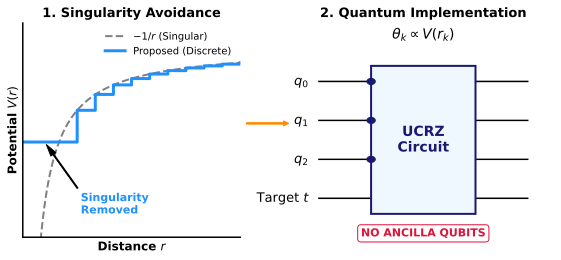

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# グラフのスタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Figureの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('white')

# ==========================================
# 1. 左側：ポテンシャル（Problem & Solution）
# ==========================================
# 連続的なクーロンポテンシャル（比較用）
r_continuous = np.linspace(0.01, 3.0, 500)
v_coulomb = -1 / r_continuous

# グリッドの離散化設定（Δr）
dr = 0.25
r_cutoff = 0.5  # 特異点回避のための実効距離

# 離散グリッド点（0, dr, 2dr, 3dr...）
r_grid = np.arange(0, 3.0 + dr, dr)
# 各グリッド点でのポテンシャル値を計算（r < r_cutoff は値を固定して特異点を回避）
v_grid = -1 / np.maximum(r_grid, r_cutoff)

# グラフの描画
# 従来のクーロンポテンシャル（破線）
ax1.plot(r_continuous, v_coulomb, '--', color='gray', linewidth=2, label='$-1/r$ (Singular)')
# 提案手法のポテンシャル（階段状に描画するため step 関数を使用）
ax1.step(r_grid, v_grid, where='post', color='dodgerblue', linewidth=3, label='Proposed (Discrete)')

# 軸とラベルの設定
ax1.set_xlim(0, 3)
ax1.set_ylim(-4, 0.5)
ax1.set_xlabel('Distance $r$', fontweight='bold')
ax1.set_ylabel('Potential $V(r)$', fontweight='bold')
ax1.set_xticks([]) # TOC図としてスッキリさせるため目盛りを消去
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 注釈と凡例
ax1.annotate('Singularity\nRemoved', xy=(0.3, -2.0), xytext=(0.8, -3.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=11, fontweight='bold', color='dodgerblue')
ax1.legend(loc='upper right', frameon=False, fontsize=10)
ax1.set_title('1. Singularity Avoidance', fontsize=13, fontweight='bold')

# ==========================================
# 2. 右側：量子回路（Implementation）
# ==========================================
ax2.axis('off')
ax2.set_xlim(0, 5)
ax2.set_ylim(-1, 4.5)

# Qubitのラインを描画
y_coords = [3, 2, 1, 0]
labels = ['$q_0$', '$q_1$', '$q_2$', 'Target $t$']
for i, y in enumerate(y_coords):
    ax2.plot([0.5, 4.5], [y, y], color='black', lw=1.5)
    ax2.text(0.3, y, labels[i], va='center', ha='right', fontsize=13)

# UCRZブロックの描画
rect = patches.Rectangle((1.5, -0.4), 2.0, 3.8, linewidth=2, 
                         edgecolor='midnightblue', facecolor='aliceblue', zorder=2)
ax2.add_patch(rect)
ax2.text(2.5, 1.5, 'UCRZ\nCircuit', va='center', ha='center', 
         fontsize=14, fontweight='bold', color='midnightblue', zorder=3)

# コントロールビットの黒丸を描画
for y in [3, 2, 1]:
    circle = patches.Circle((1.5, y), 0.08, color='midnightblue', zorder=4)
    ax2.add_patch(circle)

# アピールポイントのテキスト
ax2.text(2.5, 4.2, r'$\theta_k \propto V(r_k)$', va='center', ha='center', fontsize=14, fontweight='bold')
ax2.text(2.5, -0.9, 'NO ANCILLA QUBITS', va='center', ha='center', 
         fontsize=11, color='crimson', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", edgecolor='crimson', facecolor='white'))

ax2.set_title('2. Quantum Implementation', fontsize=13, fontweight='bold')

# ==========================================
# 3. 中央：2つの図を繋ぐ矢印
# ==========================================
plt.subplots_adjust(wspace=0.1)
arrow = patches.FancyArrowPatch((0.44, 0.5), (0.52, 0.5), transform=fig.transFigure,
                                color='darkorange', zorder=10,
                                arrowstyle='simple, tail_width=1.5, head_width=5, head_length=5')
fig.patches.append(arrow)

# ==========================================
# 保存と表示
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('TOC_Graphic_Stepped.png', dpi=300, bbox_inches='tight')
plt.savefig('TOC_Graphic_Stepped.pdf', bbox_inches='tight')

plt.show()

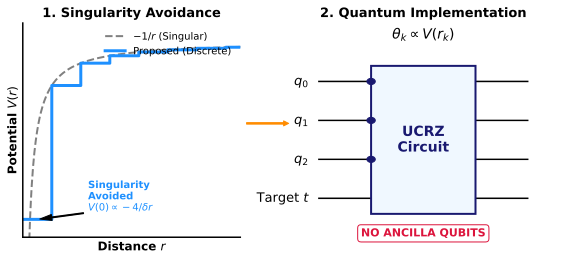

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# グラフのスタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Figureの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('white')

# ==========================================
# 1. 左側：ポテンシャル（Problem & Solution）
# ==========================================
# 連続的なクーロンポテンシャル（比較用）
r_continuous = np.linspace(0.01, 3.0, 500)
v_coulomb = -1 / r_continuous

# グリッドの離散化設定（Δr）
dr = 0.4  # 見栄えのバランスが良い0.4を採用

# 離散グリッド点（0, dr, 2dr, 3dr...）
r_grid = np.arange(0, 3.0 + dr, dr)

# 各グリッド点でのポテンシャル値を計算
v_grid = np.zeros_like(r_grid)
v_grid[0] = -4.0 / dr        # r=0 近傍の特異点回避ポテンシャル
v_grid[1:] = -1.0 / r_grid[1:] # r >= dr では通常の -1/r

# グラフの描画
# 従来のクーロンポテンシャル（破線）
ax1.plot(r_continuous, v_coulomb, '--', color='gray', linewidth=2, label='$-1/r$ (Singular)')
# 提案手法のポテンシャル（階段状に描画：where='post' により各ステップの幅が dr に揃う）
ax1.step(r_grid, v_grid, where='post', color='dodgerblue', linewidth=3, label='Proposed (Discrete)')

# 軸とラベルの設定（V(0) = -10 が見えるようにY軸の下限を拡張）
ax1.set_xlim(0, 3)
ax1.set_ylim(-11, 1.0)
ax1.set_xlabel('Distance $r$', fontweight='bold')
ax1.set_ylabel('Potential $V(r)$', fontweight='bold')
ax1.set_xticks([]) 
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 注釈と凡例（矢印の指す位置を一番深い V(0) のステップの中心に調整）
ax1.annotate('Singularity\nAvoided\n$V(0) \propto -4/\delta r$', 
             xy=(dr/2, v_grid[0]), xytext=(0.9, -9.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold', color='dodgerblue')
ax1.legend(loc='upper right', frameon=False, fontsize=10)
ax1.set_title('1. Singularity Avoidance', fontsize=13, fontweight='bold')

# ==========================================
# 2. 右側：量子回路（Implementation）
# ==========================================
ax2.axis('off')
ax2.set_xlim(0, 5)
ax2.set_ylim(-1, 4.5)

# Qubitのラインを描画
y_coords = [3, 2, 1, 0]
labels = ['$q_0$', '$q_1$', '$q_2$', 'Target $t$']
for i, y in enumerate(y_coords):
    ax2.plot([0.5, 4.5], [y, y], color='black', lw=1.5)
    ax2.text(0.3, y, labels[i], va='center', ha='right', fontsize=13)

# UCRZブロックの描画
rect = patches.Rectangle((1.5, -0.4), 2.0, 3.8, linewidth=2, 
                         edgecolor='midnightblue', facecolor='aliceblue', zorder=2)
ax2.add_patch(rect)
ax2.text(2.5, 1.5, 'UCRZ\nCircuit', va='center', ha='center', 
         fontsize=14, fontweight='bold', color='midnightblue', zorder=3)

# コントロールビットの黒丸を描画
for y in [3, 2, 1]:
    circle = patches.Circle((1.5, y), 0.08, color='midnightblue', zorder=4)
    ax2.add_patch(circle)

# アピールポイントのテキスト
ax2.text(2.5, 4.2, r'$\theta_k \propto V(r_k)$', va='center', ha='center', fontsize=14, fontweight='bold')
ax2.text(2.5, -0.9, 'NO ANCILLA QUBITS', va='center', ha='center', 
         fontsize=11, color='crimson', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", edgecolor='crimson', facecolor='white'))

ax2.set_title('2. Quantum Implementation', fontsize=13, fontweight='bold')

# ==========================================
# 3. 中央：2つの図を繋ぐ矢印
# ==========================================
plt.subplots_adjust(wspace=0.1)
arrow = patches.FancyArrowPatch((0.44, 0.5), (0.52, 0.5), transform=fig.transFigure,
                                color='darkorange', zorder=10,
                                arrowstyle='simple, tail_width=1.5, head_width=5, head_length=5')
fig.patches.append(arrow)

# ==========================================
# 保存と表示
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('TOC_Graphic_Realistic_Step.png', dpi=300, bbox_inches='tight')
plt.savefig('TOC_Graphic_Realistic_Step.pdf', bbox_inches='tight')

plt.show()

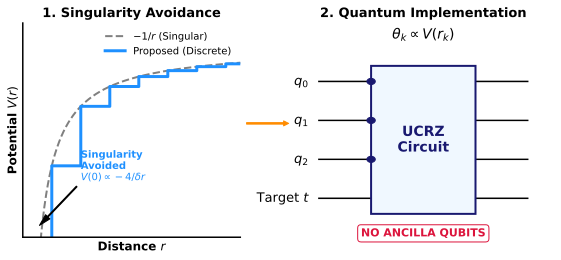

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# グラフのスタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Figureの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('white')

# ==========================================
# 1. 左側：ポテンシャル（Problem & Solution）
# ==========================================
# 連続的なクーロンポテンシャル（比較用）
r_continuous = np.linspace(0.01, 3.0, 500)
v_coulomb = -1 / r_continuous

# グリッドの離散化設定（Δr）
dr = 0.4  

# 離散グリッド点（0, dr, 2dr, 3dr...）
r_grid = np.arange(0, 3.0 + dr, dr)

# 各グリッド点でのポテンシャル値を計算
v_grid = np.zeros_like(r_grid)
v_grid[0] = -4.0 / dr        # r=0 近傍の特異点回避ポテンシャル (ここでは-10)
v_grid[1:] = -1.0 / r_grid[1:] # r >= dr では通常の -1/r

# グラフの描画
# 従来のクーロンポテンシャル（破線）
ax1.plot(r_continuous, v_coulomb, '--', color='gray', linewidth=2, label='$-1/r$ (Singular)')
# 提案手法のポテンシャル（階段状に描画）
ax1.step(r_grid, v_grid, where='post', color='dodgerblue', linewidth=3, label='Proposed (Discrete)')

# 軸とラベルの設定（スケールを1つ前の設定に戻す）
ax1.set_xlim(0, 3)
ax1.set_ylim(-4, 0.5)
ax1.set_xlabel('Distance $r$', fontweight='bold')
ax1.set_ylabel('Potential $V(r)$', fontweight='bold')
ax1.set_xticks([]) 
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 注釈と凡例（矢印の指す位置を枠の下端付近に調整）
ax1.annotate('Singularity\nAvoided\n$V(0) \propto -4/\delta r$', 
             xy=(dr/2, -3.8), xytext=(0.8, -2.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold', color='dodgerblue')
ax1.legend(loc='upper right', frameon=False, fontsize=10)
ax1.set_title('1. Singularity Avoidance', fontsize=13, fontweight='bold')

# ==========================================
# 2. 右側：量子回路（Implementation）
# ==========================================
ax2.axis('off')
ax2.set_xlim(0, 5)
ax2.set_ylim(-1, 4.5)

# Qubitのラインを描画
y_coords = [3, 2, 1, 0]
labels = ['$q_0$', '$q_1$', '$q_2$', 'Target $t$']
for i, y in enumerate(y_coords):
    ax2.plot([0.5, 4.5], [y, y], color='black', lw=1.5)
    ax2.text(0.3, y, labels[i], va='center', ha='right', fontsize=13)

# UCRZブロックの描画
rect = patches.Rectangle((1.5, -0.4), 2.0, 3.8, linewidth=2, 
                         edgecolor='midnightblue', facecolor='aliceblue', zorder=2)
ax2.add_patch(rect)
ax2.text(2.5, 1.5, 'UCRZ\nCircuit', va='center', ha='center', 
         fontsize=14, fontweight='bold', color='midnightblue', zorder=3)

# コントロールビットの黒丸を描画
for y in [3, 2, 1]:
    circle = patches.Circle((1.5, y), 0.08, color='midnightblue', zorder=4)
    ax2.add_patch(circle)

# アピールポイントのテキスト
ax2.text(2.5, 4.2, r'$\theta_k \propto V(r_k)$', va='center', ha='center', fontsize=14, fontweight='bold')
ax2.text(2.5, -0.9, 'NO ANCILLA QUBITS', va='center', ha='center', 
         fontsize=11, color='crimson', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", edgecolor='crimson', facecolor='white'))

ax2.set_title('2. Quantum Implementation', fontsize=13, fontweight='bold')

# ==========================================
# 3. 中央：2つの図を繋ぐ矢印
# ==========================================
plt.subplots_adjust(wspace=0.1)
arrow = patches.FancyArrowPatch((0.44, 0.5), (0.52, 0.5), transform=fig.transFigure,
                                color='darkorange', zorder=10,
                                arrowstyle='simple, tail_width=1.5, head_width=5, head_length=5')
fig.patches.append(arrow)

# ==========================================
# 保存と表示
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('TOC_Graphic_Final.png', dpi=300, bbox_inches='tight')
plt.savefig('TOC_Graphic_Final.pdf', bbox_inches='tight')

plt.show()

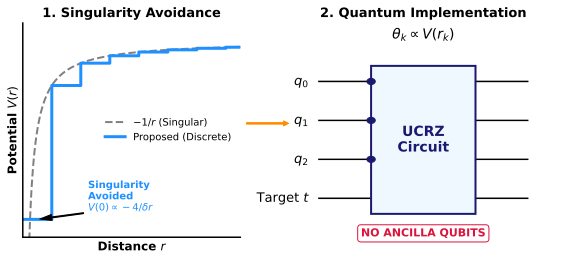

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# グラフのスタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Figureの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('white')

# ==========================================
# 1. 左側：ポテンシャル（Problem & Solution）
# ==========================================
# 連続的なクーロンポテンシャル（比較用）
r_continuous = np.linspace(0.01, 3.0, 500)
v_coulomb = -1 / r_continuous

# グリッドの離散化設定（Δr）
dr = 0.4  

# 離散グリッド点（0, dr, 2dr, 3dr...）
r_grid = np.arange(0, 3.0 + dr, dr)

# 各グリッド点でのポテンシャル値を計算
v_grid = np.zeros_like(r_grid)
v_grid[0] = -4.0 / dr        # r=0 近傍の特異点回避ポテンシャル (-10)
v_grid[1:] = -1.0 / r_grid[1:] # r >= dr では通常の -1/r

# グラフの描画
# 従来のクーロンポテンシャル（破線）
ax1.plot(r_continuous, v_coulomb, '--', color='gray', linewidth=2, label='$-1/r$ (Singular)')
# 提案手法のポテンシャル（階段状に描画）
ax1.step(r_grid, v_grid, where='post', color='dodgerblue', linewidth=3, label='Proposed (Discrete)')

# 軸とラベルの設定（深いスケールを維持）
ax1.set_xlim(0, 3)
ax1.set_ylim(-11, 1.0)
ax1.set_xlabel('Distance $r$', fontweight='bold')
ax1.set_ylabel('Potential $V(r)$', fontweight='bold')
ax1.set_xticks([]) 
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 注釈と凡例
# 矢印の位置を深いポテンシャル底に合わせる
ax1.annotate('Singularity\nAvoided\n$V(0) \propto -4/\delta r$', 
             xy=(dr/2, v_grid[0]), xytext=(0.9, -9.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, fontweight='bold', color='dodgerblue')

# 凡例を中央右側（空きスペース）に移動して衝突を回避
ax1.legend(loc='center right', frameon=False, fontsize=10)
ax1.set_title('1. Singularity Avoidance', fontsize=13, fontweight='bold')

# ==========================================
# 2. 右側：量子回路（Implementation）
# ==========================================
ax2.axis('off')
ax2.set_xlim(0, 5)
ax2.set_ylim(-1, 4.5)

# Qubitのラインを描画
y_coords = [3, 2, 1, 0]
labels = ['$q_0$', '$q_1$', '$q_2$', 'Target $t$']
for i, y in enumerate(y_coords):
    ax2.plot([0.5, 4.5], [y, y], color='black', lw=1.5)
    ax2.text(0.3, y, labels[i], va='center', ha='right', fontsize=13)

# UCRZブロックの描画
rect = patches.Rectangle((1.5, -0.4), 2.0, 3.8, linewidth=2, 
                         edgecolor='midnightblue', facecolor='aliceblue', zorder=2)
ax2.add_patch(rect)
ax2.text(2.5, 1.5, 'UCRZ\nCircuit', va='center', ha='center', 
         fontsize=14, fontweight='bold', color='midnightblue', zorder=3)

# コントロールビットの黒丸を描画
for y in [3, 2, 1]:
    circle = patches.Circle((1.5, y), 0.08, color='midnightblue', zorder=4)
    ax2.add_patch(circle)

# アピールポイントのテキスト
ax2.text(2.5, 4.2, r'$\theta_k \propto V(r_k)$', va='center', ha='center', fontsize=14, fontweight='bold')
ax2.text(2.5, -0.9, 'NO ANCILLA QUBITS', va='center', ha='center', 
         fontsize=11, color='crimson', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", edgecolor='crimson', facecolor='white'))

ax2.set_title('2. Quantum Implementation', fontsize=13, fontweight='bold')

# ==========================================
# 3. 中央：2つの図を繋ぐ矢印
# ==========================================
plt.subplots_adjust(wspace=0.1)
arrow = patches.FancyArrowPatch((0.44, 0.5), (0.52, 0.5), transform=fig.transFigure,
                                color='darkorange', zorder=10,
                                arrowstyle='simple, tail_width=1.5, head_width=5, head_length=5')
fig.patches.append(arrow)

# ==========================================
# 保存と表示
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.95])

OUTDIR='output/diagrams'
plt.savefig(f'{OUTDIR}/TOC_Graphic_Final_CenteredLegend.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{OUTDIR}/TOC_Graphic_Final_CenteredLegend.pdf', bbox_inches='tight')

plt.show()

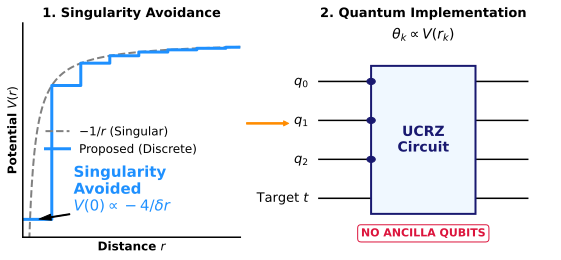

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# グラフのスタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Figureの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('white')

# ==========================================
# 1. 左側：ポテンシャル（Problem & Solution）
# ==========================================
# 連続的なクーロンポテンシャル（比較用）
r_continuous = np.linspace(0.01, 3.0, 500)
v_coulomb = -1 / r_continuous

# グリッドの離散化設定（Δr）
dr = 0.4  

# 離散グリッド点（0, dr, 2dr, 3dr...）
r_grid = np.arange(0, 3.0 + dr, dr)

# 各グリッド点でのポテンシャル値を計算
v_grid = np.zeros_like(r_grid)
v_grid[0] = -4.0 / dr        # r=0 近傍の特異点回避ポテンシャル (-10)
v_grid[1:] = -1.0 / r_grid[1:] # r >= dr では通常の -1/r

# グラフの描画
# 従来のクーロンポテンシャル（破線）
ax1.plot(r_continuous, v_coulomb, '--', color='gray', linewidth=2, label='$-1/r$ (Singular)')
# 提案手法のポテンシャル（階段状に描画）
ax1.step(r_grid, v_grid, where='post', color='dodgerblue', linewidth=3, label='Proposed (Discrete)')

# 軸とラベルの設定（深いスケールを維持）
ax1.set_xlim(0, 3)
ax1.set_ylim(-11, 1.0)
ax1.set_xlabel('Distance $r$', fontweight='bold')
ax1.set_ylabel('Potential $V(r)$', fontweight='bold')
ax1.set_xticks([]) 
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 注釈と凡例
# フォントサイズを1.5倍(15)にし、文字が枠に収まるようxytextを少し左(0.7)へ調整
ax1.annotate('Singularity\nAvoided\n$V(0) \propto -4/\delta r$', 
             xy=(dr/2, v_grid[0]), xytext=(0.7, -9.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=15, fontweight='bold', color='dodgerblue')

# 凡例のフォントサイズを1.2倍(12)にし、bbox_to_anchorで左に寄せる (0.85付近)
ax1.legend(loc='center right', bbox_to_anchor=(0.85, 0.45), frameon=False, fontsize=12)
ax1.set_title('1. Singularity Avoidance', fontsize=13, fontweight='bold')

# ==========================================
# 2. 右側：量子回路（Implementation）
# ==========================================
ax2.axis('off')
ax2.set_xlim(0, 5)
ax2.set_ylim(-1, 4.5)

# Qubitのラインを描画
y_coords = [3, 2, 1, 0]
labels = ['$q_0$', '$q_1$', '$q_2$', 'Target $t$']
for i, y in enumerate(y_coords):
    ax2.plot([0.5, 4.5], [y, y], color='black', lw=1.5)
    ax2.text(0.3, y, labels[i], va='center', ha='right', fontsize=13)

# UCRZブロックの描画
rect = patches.Rectangle((1.5, -0.4), 2.0, 3.8, linewidth=2, 
                         edgecolor='midnightblue', facecolor='aliceblue', zorder=2)
ax2.add_patch(rect)
ax2.text(2.5, 1.5, 'UCRZ\nCircuit', va='center', ha='center', 
         fontsize=14, fontweight='bold', color='midnightblue', zorder=3)

# コントロールビットの黒丸を描画
for y in [3, 2, 1]:
    circle = patches.Circle((1.5, y), 0.08, color='midnightblue', zorder=4)
    ax2.add_patch(circle)

# アピールポイントのテキスト
ax2.text(2.5, 4.2, r'$\theta_k \propto V(r_k)$', va='center', ha='center', fontsize=14, fontweight='bold')
ax2.text(2.5, -0.9, 'NO ANCILLA QUBITS', va='center', ha='center', 
         fontsize=11, color='crimson', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", edgecolor='crimson', facecolor='white'))

ax2.set_title('2. Quantum Implementation', fontsize=13, fontweight='bold')

# ==========================================
# 3. 中央：2つの図を繋ぐ矢印
# ==========================================
plt.subplots_adjust(wspace=0.1)
arrow = patches.FancyArrowPatch((0.44, 0.5), (0.52, 0.5), transform=fig.transFigure,
                                color='darkorange', zorder=10,
                                arrowstyle='simple, tail_width=1.5, head_width=5, head_length=5')
fig.patches.append(arrow)

# ==========================================
# 保存と表示
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('TOC_Graphic_ScaledFonts.png', dpi=300, bbox_inches='tight')
plt.savefig('TOC_Graphic_ScaledFonts.pdf', bbox_inches='tight')

plt.show()

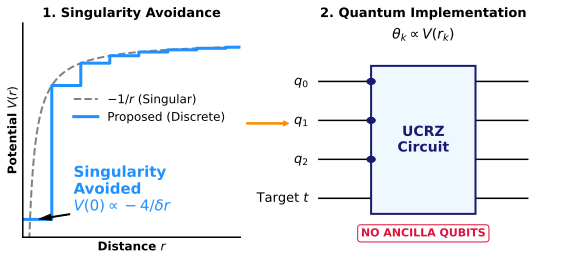

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# グラフのスタイル設定
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Figureの作成
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1.2]})
fig.patch.set_facecolor('white')

# ==========================================
# 1. 左側：ポテンシャル（Problem & Solution）
# ==========================================
# 連続的なクーロンポテンシャル（比較用）
r_continuous = np.linspace(0.01, 3.0, 500)
v_coulomb = -1 / r_continuous

# グリッドの離散化設定（Δr）
dr = 0.4  

# 離散グリッド点（0, dr, 2dr, 3dr...）
r_grid = np.arange(0, 3.0 + dr, dr)

# 各グリッド点でのポテンシャル値を計算
v_grid = np.zeros_like(r_grid)
v_grid[0] = -4.0 / dr        # r=0 近傍の特異点回避ポテンシャル (-10)
v_grid[1:] = -1.0 / r_grid[1:] # r >= dr では通常の -1/r

# グラフの描画
# 従来のクーロンポテンシャル（破線）
ax1.plot(r_continuous, v_coulomb, '--', color='gray', linewidth=2, label='$-1/r$ (Singular)')
# 提案手法のポテンシャル（階段状に描画）
ax1.step(r_grid, v_grid, where='post', color='dodgerblue', linewidth=3, label='Proposed (Discrete)')

# 軸とラベルの設定（深いスケールを維持）
ax1.set_xlim(0, 3)
ax1.set_ylim(-11, 1.0)
ax1.set_xlabel('Distance $r$', fontweight='bold')
ax1.set_ylabel('Potential $V(r)$', fontweight='bold')
ax1.set_xticks([]) 
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 注釈と凡例
# フォントサイズを1.5倍(15)にし、文字が枠に収まるようxytextを少し左(0.7)へ調整
ax1.annotate('Singularity\nAvoided\n$V(0) \propto -4/\delta r$', 
             xy=(dr/2, v_grid[0]), xytext=(0.7, -9.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=15, fontweight='bold', color='dodgerblue')

# 凡例のフォントサイズを1.2倍(12)にし、位置を右上方向へ移動させて衝突を回避
ax1.legend(loc='center right', bbox_to_anchor=(0.98, 0.60), frameon=False, fontsize=12)
ax1.set_title('1. Singularity Avoidance', fontsize=13, fontweight='bold')

# ==========================================
# 2. 右側：量子回路（Implementation）
# ==========================================
ax2.axis('off')
ax2.set_xlim(0, 5)
ax2.set_ylim(-1, 4.5)

# Qubitのラインを描画
y_coords = [3, 2, 1, 0]
labels = ['$q_0$', '$q_1$', '$q_2$', 'Target $t$']
for i, y in enumerate(y_coords):
    ax2.plot([0.5, 4.5], [y, y], color='black', lw=1.5)
    ax2.text(0.3, y, labels[i], va='center', ha='right', fontsize=13)

# UCRZブロックの描画
rect = patches.Rectangle((1.5, -0.4), 2.0, 3.8, linewidth=2, 
                         edgecolor='midnightblue', facecolor='aliceblue', zorder=2)
ax2.add_patch(rect)
ax2.text(2.5, 1.5, 'UCRZ\nCircuit', va='center', ha='center', 
         fontsize=14, fontweight='bold', color='midnightblue', zorder=3)

# コントロールビットの黒丸を描画
for y in [3, 2, 1]:
    circle = patches.Circle((1.5, y), 0.08, color='midnightblue', zorder=4)
    ax2.add_patch(circle)

# アピールポイントのテキスト
ax2.text(2.5, 4.2, r'$\theta_k \propto V(r_k)$', va='center', ha='center', fontsize=14, fontweight='bold')
ax2.text(2.5, -0.9, 'NO ANCILLA QUBITS', va='center', ha='center', 
         fontsize=11, color='crimson', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", edgecolor='crimson', facecolor='white'))

ax2.set_title('2. Quantum Implementation', fontsize=13, fontweight='bold')

# ==========================================
# 3. 中央：2つの図を繋ぐ矢印
# ==========================================
plt.subplots_adjust(wspace=0.1)
arrow = patches.FancyArrowPatch((0.44, 0.5), (0.52, 0.5), transform=fig.transFigure,
                                color='darkorange', zorder=10,
                                arrowstyle='simple, tail_width=1.5, head_width=5, head_length=5')
fig.patches.append(arrow)

# ==========================================
# 保存と表示
# ==========================================
plt.tight_layout(rect=[0, 0, 1, 0.95])

OUTDIR='output/diagrams'
plt.savefig(f'{OUTDIR}/TOC_Graphic.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{OUTDIR}/TOC_Graphic.pdf', bbox_inches='tight')

plt.show()
